# Zadanie 1: Implementacja i trenowanie modelu CNN dla zestawu danych CIFAR-100


Twoim zadaniem jest uzupełnienie brakujących fragmentów kodu w podanym szablonie, aby stworzyć działający model konwolucyjnej sieci neuronowej (CNN) do klasyfikacji obrazów z zestawu danych CIFAR-100. Poniżej znajdziesz opis zadania oraz wskazówki dotyczące brakujących miejsc w kodzie.

## Cel zadania
- Zaimplementować model CNN do rozpoznawania 100 klas obrazów z CIFAR-100.
- Uzupełnić brakujące fragmenty kodu w sekcjach modelu, treningu, walidacji i wizualizacji.
- Przeprowadzić trening z wczesnym zatrzymaniem (early stopping) i walidacją krzyżową.
- Zwizualizować wyniki treningu i predykcje modelu.

## Zestaw danych
- **CIFAR-100**: Zawiera 60 000 kolorowych obrazów (32x32 piksele) podzielonych na 100 klas (np. jabłko, rower, tygrys).
- Dane są podzielone na zestaw treningowy (50 000 obrazów) i testowy (10 000 obrazów).
- W kodzie użyto 20% danych treningowych jako zestaw walidacyjny.

## Instrukcje
Poniżej znajduje się szablon kodu z brakującymi fragmentami oznaczonymi jako `###`. Twoim zadaniem jest uzupełnienie tych fragmentów. Kod jest napisany w Pythonie z użyciem bibliotek PyTorch, torchvision, NumPy, matplotlib i scikit-learn.

### Kod do uzupełnienia

```python
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Lista klas CIFAR-100
classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 1. Przygotowanie danych
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Podział na zestaw treningowy i walidacyjny
val_size = ###  # Uzupełnij: Jaka część danych treningowych powinna być użyta do walidacji?
num_train = len(trainset)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(val_size * num_train))
train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

trainloader = DataLoader(trainset, batch_size=64, sampler=train_sampler)
valloader = DataLoader(trainset, batch_size=64, sampler=val_sampler)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# 2. Definicja modelu
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        ### Uzupełnij: Zdefiniuj warstwy sieci (np. konwolucyjne, pooling, w pełni połączone)
    
    def forward(self, x):
        ### Uzupełnij: Zdefiniuj przepływ danych przez warstwy (forward pass)
        return x

# 3. Funkcja trenująca
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        # Pętla treningowa
        model.train()
        train_loss = 0.0
        ### Uzupełnij: Zaimplementuj pętlę treningową (przebieg do przodu, obliczanie straty, aktualizacja wag)
        
        # Pętla walidacyjna
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        ### Uzupełnij: Zaimplementuj pętlę walidacyjną (obliczanie straty i dokładności)
        
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")
        
        # Wczesne zatrzymanie
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                model.load_state_dict(best_model)
                break
    
    return train_losses, val_losses, val_accuracies

# 4. Funkcje wizualizacyjne
def plot_metrics(train_losses, val_losses, val_accuracies):
    ### Uzupełnij: Zaimplementuj wykresy dla strat treningowych, walidacyjnych i dokładności walidacyjnej

def visualize_predictions(model, testloader, num_images=5):
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
    
    images = images.cpu().numpy()
    images = images * 0.5 + 0.5  # Denormalizacja
    images = np.transpose(images, (0, 2, 3, 1))
    
    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        plt.title(f'Pred: {classes[predicted[i].item()]}\nTrue: {classes[labels[i].item()]}')
        plt.axis('off')
    plt.show()

# 5. Walidacja krzyżowa
def cross_validation(k_folds=5, num_epochs=5):
    kfold = KFold(n_splits=k_folds, shuffle=True)
    results = []
    ### Uzupełnij: Zaimplementuj walidację krzyżową, trenując model dla każdego podziału i obliczając średnią dokładność
    
    print(f'Average Validation Accuracy: {np.mean(results):.2f}% ± {np.std(results):.2f}%')

# 6. Główny kod
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Trening z wczesnym zatrzymaniem
train_losses, val_losses, val_accuracies = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=10, patience=3)

# Wizualizacja
plot_metrics(train_losses, val_losses, val_accuracies)
visualize_predictions(model, testloader)

# Opcjonalna walidacja krzyżowa
cross_validation(k_folds=5, num_epochs=5)

# 7. Końcowa ewaluacja na zestawie testowym
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")
```

## Wskazówki do uzupełnienia kodu

1. **Sekcja 1: Przygotowanie danych**
   - Ustaw `val_size` na wartość określającą, jaka część danych treningowych będzie użyta do walidacji (np. 0.2 dla 20%).

2. **Sekcja 2: Definicja modelu**
   - W metodzie `__init__` zdefiniuj warstwy sieci (np. konwolucyjne `nn.Conv2d`, ReLU `nn.ReLU`, pooling `nn.MaxPool2d`, w pełni połączone `nn.Linear`).
   - W metodzie `forward` opisz, jak dane przepływają przez warstwy (np. konwolucja -> ReLU -> pooling -> spłaszczenie -> warstwy w pełni połączone).
   - Przykład: Obrazy CIFAR-100 mają rozmiar 32x32x3. Po dwóch warstwach pooling (2x2) rozmiar zmniejsza się do 8x8. Oblicz odpowiedni rozmiar dla warstwy `nn.Linear`.

3. **Sekcja 3: Funkcja trenująca**
   - W pętli treningowej:
     - Przenieś dane na urządzenie (`device`).
     - Wykonaj przebieg do przodu (`model(images)`).
     - Oblicz stratę (`criterion(outputs, labels)`).
     - Wykonaj wsteczną propagację (`loss.backward()`) i aktualizację wag (`optimizer.step()`).
   - W pętli walidacyjnej:
     - Oblicz stratę i dokładność (porównaj predykcje z etykietami).
     - Użyj `torch.no_grad()` dla wydajności.

4. **Sekcja 4: Funkcje wizualizacyjne**
   - W funkcji `plot_metrics` narysuj dwa wykresy:
     - Jeden dla strat treningowych i walidacyjnych w zależności od epoki.
     - Drugi dla dokładności walidacyjnej w zależności od epoki.
   - Użyj `matplotlib.pyplot` do tworzenia wykresów.

5. **Sekcja 5: Walidacja krzyżowa**
   - Utwórz pętle dla każdego podziału (`fold`) w `KFold`.
   - Dla każdego podziału stwórz nowe `DataLoader`y, nowy model, optimizer i criterion.
   - Trenuj model i zapisz najlepszą dokładność walidacyjną w liście `results`.

## Wymagania
- Uzupełnij wszystkie brakujące fragmenty kodu oznaczone `###`.
- Upewnij się, że kod działa bez błędów i poprawnie trenuje model.
- Model powinien osiągać rozsądną dokładność na zestawie testowym (np. >30% po 10 epokach).
- Wykresy w `plot_metrics` powinny być czytelne, z etykietami osi i legendą.
- Wyniki walidacji krzyżowej powinny pokazywać średnią dokładność i odchylenie standardowe.

## Dodatkowe wskazówki
- **Biblioteki:** Upewnij się, że masz zainstalowane `torch`, `torchvision`, `matplotlib`, `numpy`, `scikit-learn`.
- **Uruchomienie:** Kod można uruchomić w środowisku z Pythonem (np. Jupyter Notebook). GPU przyspieszy trening, ale CPU też wystarczy.
- **Debugowanie:** Sprawdzaj wymiary tensorów w metodzie `forward` (np. używając `print(x.shape)`).
- **Dokumentacja PyTorch:** Skorzystaj z dokumentacji, aby zrozumieć warstwy `nn.Conv2d`, `nn.MaxPool2d`, `nn.Linear` itp.

Powodzenia w realizacji zadania!

# Zadanie 2: # Zadanie: Implementacja i trenowanie modelu PointNet dla zbioru danych ModelNet10


Twoim zadaniem jest uzupełnienie brakujących fragmentów kodu w podanym szablonie, aby stworzyć działający model PointNet do klasyfikacji chmur punktów z zestawu danych ModelNet10. Poniżej znajdziesz opis zadania oraz wskazówki dotyczące brakujących miejsc w kodzie. Wczytywanie danych (pobieranie i ładowanie z HDF5) jest kompletne – nie zmieniaj tych części.

## Cel zadania
- Zaimplementować model PointNet do rozpoznawania 10 klas obiektów 3D (np. krzesło, stół, łóżko) na podstawie chmur punktów.
- Uzupełnić brakujące fragmenty kodu w sekcjach budowy modelu, pętli treningowej, podziału danych, walidacji krzyżowej i preprocessingu.
- Przeprowadzić trening z wczesnym zatrzymaniem (early stopping) i walidacją krzyżową.
- Zwizualizować wyniki treningu i przykładowe chmury punktów z predykcjami.

## Zestaw danych
- **ModelNet10**: Podzbiór zbioru ModelNet, zawierający chmury punktów dla 10 klas obiektów 3D (np. krzesło, stół, łóżko).
- Dane pobierane z Kaggle: https://www.kaggle.com/datasets/balraj98/modelnet10-princeton-3d-object-dataset.
- Każda próbka to chmura punktów (1024 punktów w przestrzeni 3D: x, y, z) z etykietą klasy (0-9).
- Dane są w formacie `.off` (meshe 3D), które są przetwarzane do chmur punktów.

## Instrukcje
Poniżej znajduje się szablon kodu z brakującymi fragmentami oznaczonymi jako `###`. Twoim zadaniem jest uzupełnienie tych fragmentów w sekcjach budowy modelu, pętli uczącej, podziału danych, walidacji krzyżowej i preprocessingu. Wczytywanie danych jest kompletne – nie zmieniaj tych części. Kod jest napisany w Pythonie z użyciem bibliotek PyTorch, NumPy, matplotlib, h5py i scikit-learn.

### Kod do uzupełnienia

```python
# Instalacja bibliotek (uruchom w Colab)
!pip install kagglehub torch torchvision numpy matplotlib scikit-learn h5py trimesh

import os
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold
import trimesh
import kagglehub

# Lista klas ModelNet10
classes = ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Pobieranie danych via kagglehub (kompletne – nie zmieniaj)
def download_modelnet10():
    path = kagglehub.dataset_download("balraj98/modelnet10-princeton-3d-object-dataset")
    print("Path to dataset files:", path)
    
    data_dir = os.path.join(path, 'ModelNet10')
    if not os.path.exists(data_dir):
        data_dir = path
        print(f"Brak podkatalogu ModelNet10, używam bezpośredniego path: {data_dir}")
    
    class_dir_example = os.path.join(data_dir, classes[0])  # np. bathtub
    train_dir_example = os.path.join(class_dir_example, 'train')
    test_dir_example = os.path.join(class_dir_example, 'test')
    if os.path.exists(train_dir_example) and os.path.exists(test_dir_example):
        print("Struktura potwierdzona: ModelNet10/<class_name>/train/ i test/")
    else:
        print("Błąd: Brak katalogów train/ lub test/ w", class_dir_example)
        print("Zawartość katalogu datasetu:")
        !ls -la {data_dir}
        print("\nZawartość przykładowego katalogu klasy (bathtub):")
        !ls -la {class_dir_example}
        raise FileNotFoundError("Nie znaleziono oczekiwanej struktury <class_name>/train/test")
    
    return data_dir


# Preprocessing: Samplowanie punktów z plików .off i zapis do HDF5
def preprocess_modelnet10(num_points=1024):
    """Przetwarza pliki .off do chmur punktów i zapisuje do HDF5."""
    h5_path = '/content/data/modelnet10.h5'
    if os.path.exists(h5_path):
        print("Preprocessed dane już istnieją w", h5_path)
        return h5_path
    
    data_dir = download_modelnet10()
    os.makedirs('/content/data', exist_ok=True)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    for split in ['train', 'test']:
        X_split, y_split = (X_train, y_train) if split == 'train' else (X_test, y_test)
        print(f"Przetwarzanie {split} set...")
        
        for class_name in classes:
            class_dir = os.path.join(data_dir, class_name, split)  # np. ModelNet10/bathtub/train/
            if not os.path.exists(class_dir):
                print(f"Uwaga: Katalog {class_dir} nie istnieje, pomijam klasę {class_name} w {split}")
                continue
            
            off_files = [f for f in os.listdir(class_dir) if f.endswith('.off')]
            print(f"  Klasa {class_name} ({split}): {len(off_files)} plików .off")
            
            for file in off_files:
                file_path = os.path.join(class_dir, file)
                try:
                    mesh = trimesh.load(file_path)
                    points, _ = trimesh.sample.sample_surface(mesh, num_points)
                    points = points - np.mean(points, axis=0)  # Centrowanie
                    points /= np.max(np.linalg.norm(points, axis=1)) + 1e-6  # Skalowanie
                    X_split.append(points)
                    y_split.append(class_to_idx[class_name])
                except Exception as e:
                    print(f"    Błąd przy pliku {file_path}: {e}")
        
        if split == 'train':
            X_train = np.array(X_train)
            y_train = np.array(y_split)
        else:
            X_test = np.array(X_split)
            y_test = np.array(y_split)
    
    # Zapisz do HDF5
    with h5py.File(h5_path, 'w') as hdf:
        hdf.create_dataset('X_train', data=X_train)
        hdf.create_dataset('y_train', data=y_train)
        hdf.create_dataset('X_test', data=X_test)
        hdf.create_dataset('y_test', data=y_test)
    
    print(f"Preprocessing zakończony. Kształty: Train {X_train.shape}, Test {X_test.shape}")
    return h5_path

# Przygotowanie danych (kompletne – nie zmieniaj)
class ModelNet10_Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data)  # (N_samples, N_points, 3)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def load_data():
    h5_path = preprocess_modelnet10()
    
    with h5py.File(h5_path, 'r') as hdf:
        X_train = hdf['X_train'][:]
        y_train = hdf['y_train'][:]
        X_test = hdf['X_test'][:]
        y_test = hdf['y_test'][:]
    
    val_size = 0.2
    num_train = len(X_train)
    indices = list(range(num_train))
    np.random.shuffle(indices)
    split = int(np.floor(val_size * num_train))
    train_idx, val_idx = indices[split:], indices[:split]
    
    trainset = ModelNet10_Dataset(X_train[train_idx], y_train[train_idx])
    valset = ModelNet10_Dataset(X_train[val_idx], y_train[val_idx])
    testset = ModelNet10_Dataset(X_test, y_test)
    
    trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
    valloader = DataLoader(valset, batch_size=32, shuffle=False)
    testloader = DataLoader(testset, batch_size=32, shuffle=False)
    
    print(f"Dane załadowane: Train {len(trainset)}, Val {len(valset)}, Test {len(testset)}")
    return trainloader, valloader, testloader

# Definicja modelu PointNet (uzupełnij brakujące fragmenty)
class TNet(nn.Module):
    def __init__(self, k=3):
        super(TNet, self).__init__()
        self.k = k
        ### Uzupełnij: Zdefiniuj warstwy MLP dla TNet (Conv1d, Linear, BatchNorm1d, Dropout)
    
    def forward(self, x):
        ### Uzupełnij: Przepływ danych przez TNet, dodaj macierz tożsamościową i softmax
    
class PointNet(nn.Module):
    def __init__(self, num_classes=10, num_points=1024):
        super(PointNet, self).__init__()
        self.num_classes = num_classes
        self.num_points = num_points
        ### Uzupełnij: Zdefiniuj TNet1, Conv1d, BatchNorm1d, TNet2, Linear dla klasyfikacji
    
    def forward(self, x):
        ### Uzupełnij: Przepływ danych: transpose, TNet1, Conv, max pooling, TNet2, FC layers, logsoftmax

# Funkcja trenująca (uzupełnij brakujące fragmenty)
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        ### Uzupełnij: Pętla treningowa (zero_grad, forward, loss, backward, step, sumuj loss)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        ### Uzupełnij: Pętla walidacyjna (no_grad, forward, loss, predicted, sumuj accuracy)
        
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")
        
        ### Uzupełnij: Early stopping (sprawdź val_loss, zapisz model, licznik no_improve)
    
    return train_losses, val_losses, val_accuracies

# Funkcje wizualizacyjne (kompletne – nie zmieniaj)
def plot_metrics(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, testloader, num_samples=5):
    device = next(model.parameters()).device
    model.eval()
    points, labels = next(iter(testloader))
    points, labels = points[:num_samples].to(device), labels[:num_samples].to(device)
    
    with torch.no_grad():
        outputs = model(points)
        _, predicted = torch.max(outputs, 1)
    
    points = points.cpu().numpy()
    
    fig = plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        ax = fig.add_subplot(1, num_samples, i+1, projection='3d')
        ax.scatter(points[i, :, 0], points[i, :, 1], points[i, :, 2], s=1)
        ax.set_title(f'Pred: {classes[predicted[i].item()]}\nTrue: {classes[labels[i].item()]}')
        ax.axis('off')
    plt.show()

# Walidacja krzyżowa (uzupełnij brakujące fragmenty)
def cross_validation(k_folds=3, num_epochs=5):
    with h5py.File('/content/data/modelnet10.h5', 'r') as hdf:
        full_data = hdf['X_train'][:]
        full_labels = hdf['y_train'][:]
    
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []
    
    ### Uzupełnij: Pętla po foldach, twórz train/val set, DataLoader'y, nowy model, criterion, optimizer, trenuj, zapisuj max accuracy
    
    print(f'Average Validation Accuracy: {np.mean(results):.2f}% ± {np.std(results):.2f}%')

# Główny kod (kompletny – nie zmieniaj)
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    trainloader, valloader, testloader = load_data()
    
    model = PointNet(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_losses, val_losses, val_accuracies = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=20, patience=5)
    
    plot_metrics(train_losses, val_losses, val_accuracies)
    visualize_predictions(model, testloader)
    
    cross_validation(k_folds=3, num_epochs=5)
    
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for points, labels in testloader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    print(f"Test Accuracy: {100 * correct / total:.2f}%")
```

## Wskazówki do uzupełnienia kodu

1. **Budowa modelu (TNet i PointNet)**:
   - W `__init__` zdefiniuj warstwy (Conv1d, Linear, BatchNorm1d).
   - W `forward` opisz przepływ: Conv1d, ReLU, max pooling, TNet, softmax.

2. **Pętla ucząca (train_model)**:
   - Uzupełnij pętle treningową i walidacyjną (zero_grad, forward, loss, backward).
   - Dodaj early stopping.

3. **Podział danych (load_data)**:
   - Uzupełnij stratyfikowany podział (użyj train_test_split z stratify).

4. **Walidacja krzyżowa (cross_validation)**:
   - Uzupełnij pętlę po foldach, twórz DataLoader'y, model, trenuj, zapisuj accuracy.

## Wymagania
- Uzupełnij wszystkie brakujące fragmenty oznaczone `###`.
- Upewnij się, że kod działa bez błędów i poprawnie trenuje model.
- Model powinien osiągać rozsądną dokładność na zestawie testowym (np. >80% po 20 epokach).
- Wykresy w `plot_metrics` powinny być czytelne, z etykietami osi i legendą.
- Wyniki walidacji krzyżowej powinny pokazywać średnią dokładność i odchylenie standardowe.

Zadanie 1

100%|██████████| 169M/169M [00:03<00:00, 44.1MB/s]


Epoch 1, Train Loss: 4.008, Val Loss: 3.489, Val Accuracy: 17.16%
Epoch 2, Train Loss: 3.434, Val Loss: 3.076, Val Accuracy: 24.19%
Epoch 3, Train Loss: 3.139, Val Loss: 2.874, Val Accuracy: 28.04%
Epoch 4, Train Loss: 2.935, Val Loss: 2.681, Val Accuracy: 32.61%
Epoch 5, Train Loss: 2.763, Val Loss: 2.577, Val Accuracy: 34.42%
Epoch 6, Train Loss: 2.635, Val Loss: 2.467, Val Accuracy: 36.47%
Epoch 7, Train Loss: 2.519, Val Loss: 2.408, Val Accuracy: 37.46%
Epoch 8, Train Loss: 2.422, Val Loss: 2.330, Val Accuracy: 39.35%
Epoch 9, Train Loss: 2.318, Val Loss: 2.329, Val Accuracy: 39.50%
Epoch 10, Train Loss: 2.238, Val Loss: 2.304, Val Accuracy: 39.96%


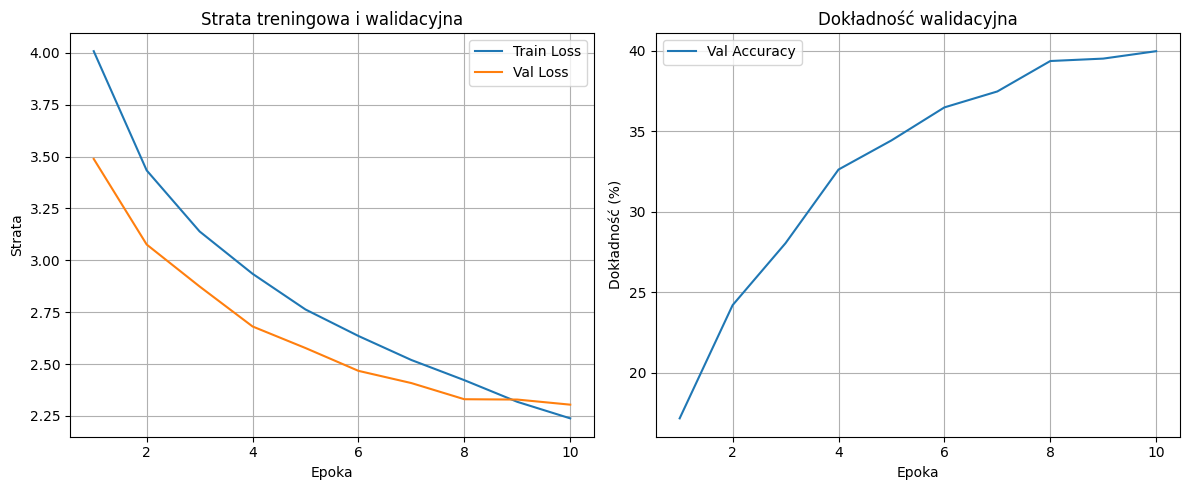

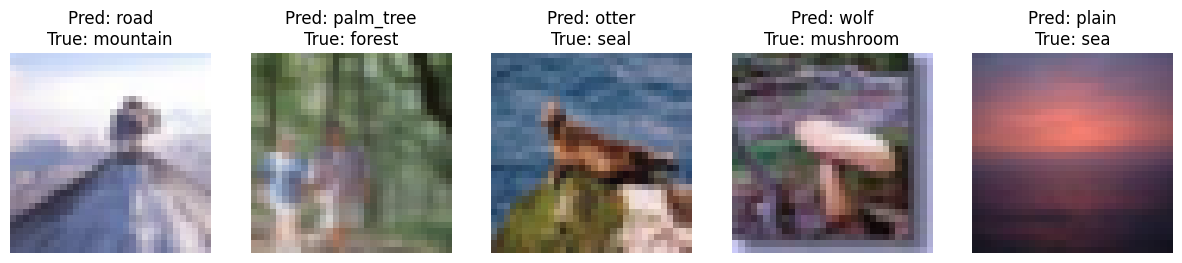


Fold 1/5
Epoch 1, Train Loss: 4.063, Val Loss: 3.573, Val Accuracy: 15.41%
Epoch 2, Train Loss: 3.515, Val Loss: 3.165, Val Accuracy: 23.23%
Epoch 3, Train Loss: 3.226, Val Loss: 2.941, Val Accuracy: 27.42%
Epoch 4, Train Loss: 3.028, Val Loss: 2.777, Val Accuracy: 30.53%
Epoch 5, Train Loss: 2.871, Val Loss: 2.628, Val Accuracy: 33.11%
Best Validation Accuracy for fold 1: 33.11%

Fold 2/5
Epoch 1, Train Loss: 4.047, Val Loss: 3.509, Val Accuracy: 16.68%
Epoch 2, Train Loss: 3.515, Val Loss: 3.144, Val Accuracy: 23.81%
Epoch 3, Train Loss: 3.251, Val Loss: 2.918, Val Accuracy: 27.64%
Epoch 4, Train Loss: 3.077, Val Loss: 2.827, Val Accuracy: 30.10%
Epoch 5, Train Loss: 2.940, Val Loss: 2.675, Val Accuracy: 32.26%
Best Validation Accuracy for fold 2: 32.26%

Fold 3/5
Epoch 1, Train Loss: 4.059, Val Loss: 3.582, Val Accuracy: 15.24%
Epoch 2, Train Loss: 3.498, Val Loss: 3.148, Val Accuracy: 22.52%
Epoch 3, Train Loss: 3.190, Val Loss: 2.918, Val Accuracy: 27.14%
Epoch 4, Train Loss: 2.9

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Lista klas CIFAR-100
classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# 1. Przygotowanie danych
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Podział na zestaw treningowy i walidacyjny
val_size = 0.2  # 20% danych treningowych na walidację
num_train = len(trainset)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(val_size * num_train))
train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

trainloader = DataLoader(trainset, batch_size=64, sampler=train_sampler)
valloader = DataLoader(trainset, batch_size=64, sampler=val_sampler)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# 2. Definicja modelu
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)

        # Wejście: 32x32
        # po pool1 - 16x16
        # po pool2 - 8x8
        # po pool3 - 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # [B, 32, 16, 16]
        x = self.pool(self.relu(self.conv2(x)))   # [B, 64, 8, 8]
        x = self.pool(self.relu(self.conv3(x)))   # [B, 128, 4, 4]

        x = torch.flatten(x, 1)                   # [B, 128*4*4]
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 3. Funkcja trenująca
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        # Pętla treningowa
        model.train()
        train_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss = train_loss / len(trainloader.sampler)
        train_losses.append(train_loss)

        # Pętla walidacyjna
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(valloader.sampler)
        val_accuracy = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")

        # Wczesne zatrzymanie
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                model.load_state_dict(best_model)
                break

    if best_model is not None:
        model.load_state_dict(best_model)

    return train_losses, val_losses, val_accuracies

# 4. Funkcje wizualizacyjne
def plot_metrics(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.title('Strata treningowa i walidacyjna')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoka')
    plt.ylabel('Dokładność (%)')
    plt.title('Dokładność walidacyjna')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def visualize_predictions(model, testloader, num_images=5):
    model.eval()
    images, labels = next(iter(testloader))
    images, labels = images[:num_images].to(device), labels[:num_images].to(device)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    images = images.cpu().numpy()
    labels = labels.cpu()
    predicted = predicted.cpu()

    images = images * 0.5 + 0.5  # Denormalizacja
    images = np.transpose(images, (0, 2, 3, 1))

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        plt.title(f'Pred: {classes[predicted[i].item()]}\nTrue: {classes[labels[i].item()]}')
        plt.axis('off')
    plt.show()

# 5. Walidacja krzyżowa
def cross_validation(k_folds=5, num_epochs=5):
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []

    indices = np.arange(len(trainset))

    for fold, (train_ids, val_ids) in enumerate(kfold.split(indices)):
        print(f'\nFold {fold + 1}/{k_folds}')

        train_sampler = SubsetRandomSampler(train_ids)
        val_sampler = SubsetRandomSampler(val_ids)

        fold_trainloader = DataLoader(trainset, batch_size=64, sampler=train_sampler)
        fold_valloader = DataLoader(trainset, batch_size=64, sampler=val_sampler)

        model = SimpleCNN()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        _, _, val_accuracies = train_model(
            model,
            fold_trainloader,
            fold_valloader,
            criterion,
            optimizer,
            num_epochs=num_epochs,
            patience=3
        )

        best_fold_acc = max(val_accuracies)
        results.append(best_fold_acc)
        print(f'Best Validation Accuracy for fold {fold + 1}: {best_fold_acc:.2f}%')

    print(f'\nAverage Validation Accuracy: {np.mean(results):.2f}% ± {np.std(results):.2f}%')

# 6. Główny kod
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Trening z wczesnym zatrzymaniem
train_losses, val_losses, val_accuracies = train_model(
    model, trainloader, valloader, criterion, optimizer, num_epochs=10, patience=3
)

# Wizualizacja
plot_metrics(train_losses, val_losses, val_accuracies)
visualize_predictions(model, testloader)

# Opcjonalna walidacja krzyżowa
cross_validation(k_folds=5, num_epochs=5)

# 7. Końcowa ewaluacja na zestawie testowym
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Zadanie 2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.5/740.5 kB 19.8 MB/s eta 0:00:00
Using device: cuda
Using Colab cache for faster access to the 'modelnet10-princeton-3d-object-dataset' dataset.
Path to dataset files: /kaggle/input/modelnet10-princeton-3d-object-dataset
Struktura potwierdzona: ModelNet10/<class_name>/train/ i test/
Przetwarzanie train set...
  Klasa bathtub (train): 106 plików .off
  Klasa bed (train): 515 plików .off
  Klasa chair (train): 889 plików .off
  Klasa desk (train): 200 plików .off
  Klasa dresser (train): 200 plików .off
  Klasa monitor (train): 465 plików .off
  Klasa night_stand (train): 200 plików .off
  Klasa sofa (train): 680 plików .off
  Klasa table (train): 392 plików .off
  Klasa toilet (train): 344 plików .off
Przetwarzanie test set...
  Klasa bathtub (test): 50 plików .off
  Klasa bed (test): 100 plików .off
  Klasa chair (test): 100 plików .off
  Klasa desk (test): 86 plików .off
  Klasa dresser (test): 86 plików .off
  Klasa monitor (test): 100 

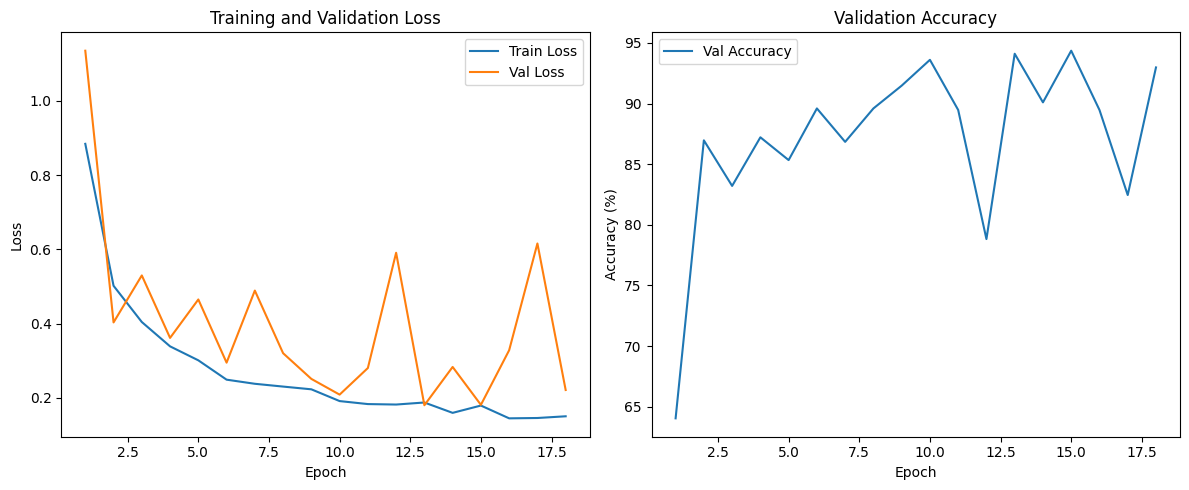

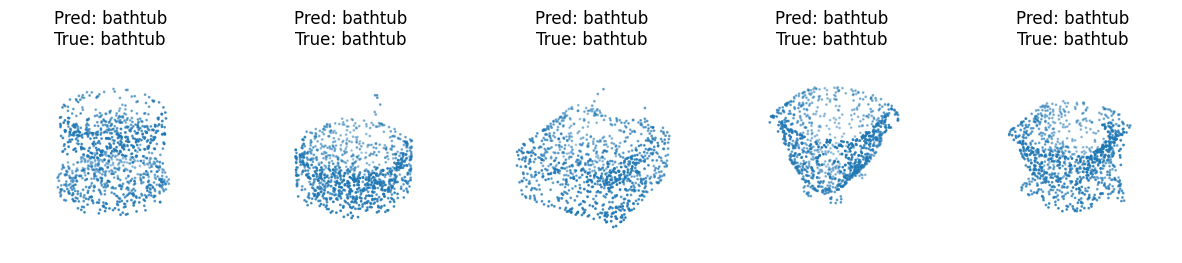


Fold 1/3
Epoch 1/5, Train Loss: 0.954, Val Loss: 0.715, Val Accuracy: 79.11%
Epoch 2/5, Train Loss: 0.517, Val Loss: 0.538, Val Accuracy: 80.17%
Epoch 3/5, Train Loss: 0.465, Val Loss: 0.550, Val Accuracy: 81.37%
Epoch 4/5, Train Loss: 0.388, Val Loss: 0.383, Val Accuracy: 86.40%
Epoch 5/5, Train Loss: 0.339, Val Loss: 0.338, Val Accuracy: 87.38%
Best Validation Accuracy for fold 1: 87.38%

Fold 2/3
Epoch 1/5, Train Loss: 0.953, Val Loss: 0.928, Val Accuracy: 67.52%
Epoch 2/5, Train Loss: 0.632, Val Loss: 0.428, Val Accuracy: 85.41%
Epoch 3/5, Train Loss: 0.471, Val Loss: 0.485, Val Accuracy: 83.31%
Epoch 4/5, Train Loss: 0.403, Val Loss: 0.433, Val Accuracy: 86.39%
Epoch 5/5, Train Loss: 0.379, Val Loss: 0.679, Val Accuracy: 78.57%
Early stopping after 5 epochs
Best Validation Accuracy for fold 2: 86.39%

Fold 3/3
Epoch 1/5, Train Loss: 0.993, Val Loss: 0.851, Val Accuracy: 73.31%
Epoch 2/5, Train Loss: 0.584, Val Loss: 0.715, Val Accuracy: 78.87%
Epoch 3/5, Train Loss: 0.419, Val Lo

In [2]:
# Instalacja bibliotek (uruchom w Colab)
!pip install kagglehub torch torchvision numpy matplotlib scikit-learn h5py trimesh

import os
import copy
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold, StratifiedKFold
import trimesh
import kagglehub

# Lista klas ModelNet10
classes = ['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Pobieranie danych via kagglehub (kompletne – nie zmieniaj)
def download_modelnet10():
    path = kagglehub.dataset_download("balraj98/modelnet10-princeton-3d-object-dataset")
    print("Path to dataset files:", path)

    data_dir = os.path.join(path, 'ModelNet10')
    if not os.path.exists(data_dir):
        data_dir = path
        print(f"Brak podkatalogu ModelNet10, używam bezpośredniego path: {data_dir}")

    class_dir_example = os.path.join(data_dir, classes[0])  # np. bathtub
    train_dir_example = os.path.join(class_dir_example, 'train')
    test_dir_example = os.path.join(class_dir_example, 'test')
    if os.path.exists(train_dir_example) and os.path.exists(test_dir_example):
        print("Struktura potwierdzona: ModelNet10/<class_name>/train/ i test/")
    else:
        print("Błąd: Brak katalogów train/ lub test/ w", class_dir_example)
        print("Zawartość katalogu datasetu:")
        !ls -la {data_dir}
        print("\nZawartość przykładowego katalogu klasy (bathtub):")
        !ls -la {class_dir_example}
        raise FileNotFoundError("Nie znaleziono oczekiwanej struktury <class_name>/train/test")

    return data_dir


# Preprocessing: Samplowanie punktów z plików .off i zapis do HDF5
def preprocess_modelnet10(num_points=1024):
    """Przetwarza pliki .off do chmur punktów i zapisuje do HDF5."""
    h5_path = '/content/data/modelnet10.h5'
    if os.path.exists(h5_path):
        print("Preprocessed dane już istnieją w", h5_path)
        return h5_path

    data_dir = download_modelnet10()
    os.makedirs('/content/data', exist_ok=True)

    X_train, y_train = [], []
    X_test, y_test = [], []

    for split in ['train', 'test']:
        X_split, y_split = (X_train, y_train) if split == 'train' else (X_test, y_test)
        print(f"Przetwarzanie {split} set...")

        for class_name in classes:
            class_dir = os.path.join(data_dir, class_name, split)  # np. ModelNet10/bathtub/train/
            if not os.path.exists(class_dir):
                print(f"Uwaga: Katalog {class_dir} nie istnieje, pomijam klasę {class_name} w {split}")
                continue

            off_files = [f for f in os.listdir(class_dir) if f.endswith('.off')]
            print(f"  Klasa {class_name} ({split}): {len(off_files)} plików .off")

            for file in off_files:
                file_path = os.path.join(class_dir, file)
                try:
                    mesh = trimesh.load(file_path)
                    points, _ = trimesh.sample.sample_surface(mesh, num_points)
                    points = points - np.mean(points, axis=0)  # Centrowanie
                    points /= np.max(np.linalg.norm(points, axis=1)) + 1e-6  # Skalowanie
                    X_split.append(points)
                    y_split.append(class_to_idx[class_name])
                except Exception as e:
                    print(f"    Błąd przy pliku {file_path}: {e}")

        if split == 'train':
            X_train = np.array(X_train)
            y_train = np.array(y_split)
        else:
            X_test = np.array(X_split)
            y_test = np.array(y_split)

    # Zapisz do HDF5
    with h5py.File(h5_path, 'w') as hdf:
        hdf.create_dataset('X_train', data=X_train)
        hdf.create_dataset('y_train', data=y_train)
        hdf.create_dataset('X_test', data=X_test)
        hdf.create_dataset('y_test', data=y_test)

    print(f"Preprocessing zakończony. Kształty: Train {X_train.shape}, Test {X_test.shape}")
    return h5_path

# Przygotowanie danych (kompletne – nie zmieniaj)
class ModelNet10_Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data)  # (N_samples, N_points, 3)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

def load_data():
    h5_path = preprocess_modelnet10()

    with h5py.File(h5_path, 'r') as hdf:
        X_train = hdf['X_train'][:]
        y_train = hdf['y_train'][:]
        X_test = hdf['X_test'][:]
        y_test = hdf['y_test'][:]

    val_size = 0.2
    num_train = len(X_train)
    indices = list(range(num_train))
    np.random.shuffle(indices)
    split = int(np.floor(val_size * num_train))
    train_idx, val_idx = indices[split:], indices[:split]

    trainset = ModelNet10_Dataset(X_train[train_idx], y_train[train_idx])
    valset = ModelNet10_Dataset(X_train[val_idx], y_train[val_idx])
    testset = ModelNet10_Dataset(X_test, y_test)

    trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
    valloader = DataLoader(valset, batch_size=32, shuffle=False)
    testloader = DataLoader(testset, batch_size=32, shuffle=False)

    print(f"Dane załadowane: Train {len(trainset)}, Val {len(valset)}, Test {len(testset)}")
    return trainloader, valloader, testloader

# Definicja modelu PointNet (uzupełnij brakujące fragmenty)
class TNet(nn.Module):
    def __init__(self, k=3):
        super(TNet, self).__init__()
        self.k = k

        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k * k)

        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        batch_size = x.size(0)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))

        x = torch.max(x, 2)[0]

        x = self.relu(self.bn4(self.fc1(x)))
        x = self.relu(self.bn5(self.dropout(self.fc2(x))))
        x = self.fc3(x)

        identity = torch.eye(self.k, device=x.device).unsqueeze(0).repeat(batch_size, 1, 1)
        x = x.view(-1, self.k, self.k) + identity

        return x

class PointNet(nn.Module):
    def __init__(self, num_classes=10, num_points=1024):
        super(PointNet, self).__init__()
        self.num_classes = num_classes
        self.num_points = num_points

        self.tnet1 = TNet(k=3)
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)

        self.tnet2 = TNet(k=64)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.bn3 = nn.BatchNorm1d(1024)

        self.fc1 = nn.Linear(1024, 512)
        self.bn4 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn5 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # x: (B, N, 3)
        x = x.transpose(1, 2)  # (B, 3, N)

        trans_input = self.tnet1(x)  # (B, 3, 3)
        x = torch.bmm(trans_input, x)  # (B, 3, N)

        x = self.relu(self.bn1(self.conv1(x)))  # (B, 64, N)

        trans_feat = self.tnet2(x)  # (B, 64, 64)
        x = torch.bmm(trans_feat, x)  # (B, 64, N)

        x = self.relu(self.bn2(self.conv2(x)))  # (B, 128, N)
        x = self.relu(self.bn3(self.conv3(x)))  # (B, 1024, N)

        x = torch.max(x, 2)[0]  # global max pooling -> (B, 1024)

        x = self.relu(self.bn4(self.fc1(x)))
        x = self.relu(self.bn5(self.dropout(self.fc2(x))))
        x = self.fc3(x)  # logits

        return x

# Funkcja trenująca (uzupełnij brakujące fragmenty)
def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for points, labels in trainloader:
            points, labels = points.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(points)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * points.size(0)

        train_loss = train_loss / len(trainloader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for points, labels in valloader:
                points, labels = points.to(device), labels.to(device)

                outputs = model(points)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * points.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(valloader.dataset)
        val_accuracy = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                if best_model is not None:
                    model.load_state_dict(best_model)
                break

    if best_model is not None:
        model.load_state_dict(best_model)

    return train_losses, val_losses, val_accuracies

# Funkcje wizualizacyjne (kompletne – nie zmieniaj)
def plot_metrics(train_losses, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def visualize_predictions(model, testloader, num_samples=5):
    device = next(model.parameters()).device
    model.eval()
    points, labels = next(iter(testloader))
    points, labels = points[:num_samples].to(device), labels[:num_samples].to(device)

    with torch.no_grad():
        outputs = model(points)
        _, predicted = torch.max(outputs, 1)

    points = points.cpu().numpy()

    fig = plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        ax = fig.add_subplot(1, num_samples, i+1, projection='3d')
        ax.scatter(points[i, :, 0], points[i, :, 1], points[i, :, 2], s=1)
        ax.set_title(f'Pred: {classes[predicted[i].item()]}\nTrue: {classes[labels[i].item()]}')
        ax.axis('off')
    plt.show()

# Walidacja krzyżowa (uzupełnij brakujące fragmenty)
def cross_validation(k_folds=3, num_epochs=5):
    with h5py.File('/content/data/modelnet10.h5', 'r') as hdf:
        full_data = hdf['X_train'][:]
        full_labels = hdf['y_train'][:]

    kfold = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    results = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(full_data, full_labels)):
        print(f"\nFold {fold + 1}/{k_folds}")

        X_train_fold, y_train_fold = full_data[train_idx], full_labels[train_idx]
        X_val_fold, y_val_fold = full_data[val_idx], full_labels[val_idx]

        trainset = ModelNet10_Dataset(X_train_fold, y_train_fold)
        valset = ModelNet10_Dataset(X_val_fold, y_val_fold)

        trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
        valloader = DataLoader(valset, batch_size=32, shuffle=False)

        model = PointNet(num_classes=10)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        _, _, val_accuracies = train_model(
            model, trainloader, valloader, criterion, optimizer,
            num_epochs=num_epochs, patience=3
        )

        best_acc = max(val_accuracies)
        results.append(best_acc)
        print(f"Best Validation Accuracy for fold {fold + 1}: {best_acc:.2f}%")

    print(f'Average Validation Accuracy: {np.mean(results):.2f}% ± {np.std(results):.2f}%')

# Główny kod (kompletny – nie zmieniaj)
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    trainloader, valloader, testloader = load_data()

    model = PointNet(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, val_accuracies = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=20, patience=5)

    plot_metrics(train_losses, val_losses, val_accuracies)
    visualize_predictions(model, testloader)

    cross_validation(k_folds=3, num_epochs=5)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for points, labels in testloader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")
